At x = 2.0:
Analytical f'(x): 9.000000
Numerical f'(x):  9.000000


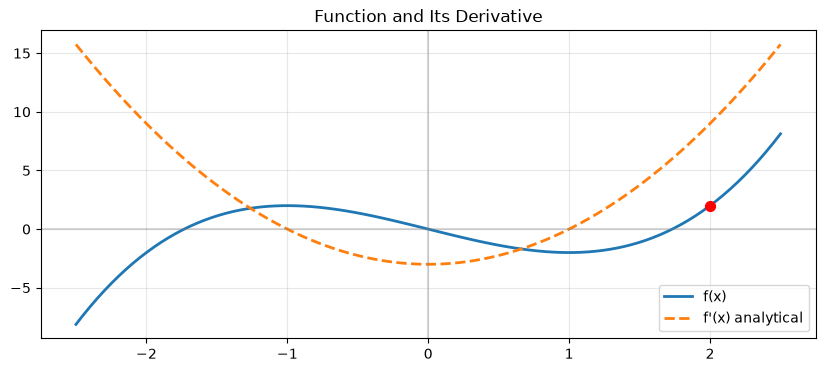

In [2]:
# DERIVATIVES, GRADIENTS & THE CHAIN RULE

# Numerical vs Analytical Derivative
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    """Simple function: f(x) = x^3 - 3x"""
    return x**3 - 3*x

def df_analytical(x):
    """Analytical derivative: f'(x) = 3x^2 - 3"""
    return 3*x**2 - 3

def df_numerical(x, h=1e-5):
    """Numerical derivative using central difference: (f(x+h) - f(x-h)) / (2h)"""
    return (f(x + h) - f(x - h)) / (2*h)

# Test at a point
x_test = 2.0
print(f"At x = {x_test}:")
print(f"Analytical f'(x): {df_analytical(x_test):.6f}")
print(f"Numerical f'(x):  {df_numerical(x_test):.6f}")

# Plot function and derivative
x = np.linspace(-2.5, 2.5, 100)
plt.figure(figsize=(10, 4))
plt.plot(x, f(x), label='f(x)', linewidth=2)
plt.plot(x, df_analytical(x), label="f'(x) analytical", linestyle='--', linewidth=2)
plt.scatter([x_test], [f(x_test)], color='red', s=50, zorder=5)
plt.axhline(0, color='gray', alpha=0.3)
plt.axvline(0, color='gray', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Function and Its Derivative')
plt.show()

# Key takeaway: The derivative tells you the slope. If the slope is positive,
# increasing x increases f(x). Gradient descent moves against the slope.

In [15]:
# Gradient of a Multi-Variable Function

def g(x):
    """g(x,y) = x^2 + y^2 (a bowl shape)"""
    return x[0]**2 + x[1]**2

def grad_g_analytical(x):
    """∇g = [2x, 2y]"""
    return np.array([2*x[0], 2*x[1]])

def grad_g_numerical(x, h=1e-5):
    """Numerical gradient using central differences for each dimension"""
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_plus = x.copy()
        x_minus = x.copy()
        x_plus[i] += h
        x_minus[i] -= h
        grad[i] = (g(x_plus) - g(x_minus)) / (2*h)
    return grad

# Test
point = np.array([1.5, -2.0])
analytical_grad = grad_g_analytical(point)
numerical_grad = grad_g_numerical(point)
print(f"At point {point}:")
print(f"Analytical gradient: {analytical_grad}")
print(f"Numerical gradient:  {numerical_grad}")
print(f"Norm of difference: {np.linalg.norm(analytical_grad - numerical_grad):.10f}")

# The gradient points in the direction of steepest ascent
# So -gradient points towards the minimum
print(f"\nSteepest ascent direction: {analytical_grad}")
print(f"Direction to minimum:       {-analytical_grad}")

# Why this matters: When training a neural network, we compute the gradient of the 
# loss with respect to every weight. Then we move each weight a tiny step opposite the 
# gradient. Repeat.

At point [ 1.5 -2. ]:
Analytical gradient: [ 3. -4.]
Numerical gradient:  [ 3. -4.]
Norm of difference: 0.0000000001

Steepest ascent direction: [ 3. -4.]
Direction to minimum:       [-3.  4.]


In [20]:
# The Chain Rule in Action

# Let's chain functions: h(x) = f(g(x))
# where g(x) = sin(x) and f(z) = z^2

def g_func(x):
    return np.sin(x)

def f_func(z):
    return z**2

def h_func(x):
    """h(x) = f(g(x)) = sin(x)^2"""
    return f_func(g_func(x))

# Analytical gradient via chain rule:
# dh/dx = f'(g(x)) * g'(x) = 2*sin(x) * cos(x)
def dh_analytical(x):
    return 2 * np.sin(x) * np.cos(x)

# Numerical verification
x_val = 1.0
num_grad = (h_func(x_val + 1e-6) - h_func(x_val - 1e-6)) / (2e-6)
ana_grad = dh_analytical(x_val)
print(f"Chain rule at x={x_val}:")
print(f"Analytical: {ana_grad:.6f}")
print(f"Numerical:  {num_grad:.6f}")

# Manually compute the intermediate gradients
z = g_func(x_val)       # sin(1.0)
dz_dx = np.cos(x_val)   # g'(x)
df_dz = 2 * z           # f'(z)
chain_result = df_dz * dz_dx
print(f"\nManual chain: df/dz * dz/dx = {df_dz:.4f} * {dz_dx:.4f} = {chain_result:.6f}")

# This is the entire secret of backpropagation. A neural network is just a long chain of 
# functions. We store intermediate values during the forward pass, then multiply gradients backward.

Chain rule at x=1.0:
Analytical: 0.909297
Numerical:  0.909297

Manual chain: df/dz * dz/dx = 1.6829 * 0.5403 = 0.909297


In [27]:
# Manual Backpropagation on a Tiny Network

# Let's do a full forward and backward pass on a mini network:
# Input: x (2D)
# Hidden layer: h = W1 @ x + b1, then ReLU
# Output: y_pred = W2 @ h + b2
# Loss: MSE = (y_pred - y_true)^2

# Define a sample data point
x = np.array([1.0, 2.0])       # input
y_true = np.array([5.0])       # target

# Initialize weights (small random)
np.random.seed(42)
W1 = np.random.randn(3, 2) * 0.1   # 3 hidden neurons, 2 inputs
b1 = np.zeros(3)
W2 = np.random.randn(1, 3) * 0.1   # 1 output, 3 hidden
b2 = np.zeros(1)

# --- Forward pass ---
z1 = W1 @ x + b1               # pre-activation (3,)
h = np.maximum(0, z1)          # ReLU (3,)
y_pred = W2 @ h + b2           # prediction (1,)
loss = np.sum((y_pred - y_true)**2)  # MSE (scalar)

print("Forward pass:")
print(f"z1 = {z1}")
print(f"h (after ReLU) = {h}")
print(f"y_pred = {y_pred}")
print(f"loss = {loss:.4f}")

# --- Backward pass (hand-derived) ---
# dL/dy_pred = 2 * (y_pred - y_true)
dL_dy_pred = 2 * (y_pred - y_true)  # shape (1,)

# dL/dW2 = dL/dy_pred * h^T (outer product)
dL_dW2 = np.outer(dL_dy_pred, h)   # (1,3)
# dL/db2 = dL/dy_pred
dL_db2 = dL_dy_pred.copy()

# dL/dh = W2^T @ dL_dy_pred
dL_dh = W2.T @ dL_dy_pred   # (3,)

# ReLU backward: gradient flows only where z1 > 0
dL_dz1 = dL_dh * (z1 > 0)   # (3,)

# dL/dW1 = dL/dz1 ⊗ x (outer product)
dL_dW1 = np.outer(dL_dz1, x)   # (3,2)
dL_db1 = dL_dz1

print("\nComputed gradients:")
print(f"dL/dW2 shape {dL_dW2.shape}:\n{dL_dW2}")
print(f"dL/dW1 shape {dL_dW1.shape}:\n{dL_dW1}")

# Manually what PyTorch's autograd does automatically. 
# The above is the same as:
# The backward pass computes the gradient of the loss with respect to every parameter by chaining local gradients.
# The chain rule is applied to each parameter, and intermediate values are stored.
# This is the essence of backpropagation.

Forward pass:
z1 = [ 0.02201856  0.36937483 -0.07024273]
h (after ReLU) = [0.02201856 0.36937483 0.        ]
y_pred = [0.03182431]
loss = 24.6828

Computed gradients:
dL/dW2 shape (1, 3):
[[-0.2187841  -3.67023806 -0.        ]]
dL/dW1 shape (3, 2):
[[-1.56916135 -3.13832269]
 [-0.76255011 -1.52510023]
 [ 0.          0.        ]]


In [31]:
# Gradient Checking (The Universal Debugger)

def gradient_check(param_name, param_value, grad_analytical, loss_fn, h=1e-6):
    """Verify analytical gradient against numerical approximation."""
    grad_numerical = np.zeros_like(param_value)
    it = np.nditer(param_value, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        old_val = param_value[idx]
        
        param_value[idx] = old_val + h
        loss_plus = loss_fn()
        param_value[idx] = old_val - h
        loss_minus = loss_fn()
        param_value[idx] = old_val  # restore
        
        grad_numerical[idx] = (loss_plus - loss_minus) / (2*h)
        it.iternext()
    
    diff = np.linalg.norm(grad_analytical - grad_numerical) / (np.linalg.norm(grad_analytical) + np.linalg.norm(grad_numerical) + 1e-8)
    print(f"{param_name}: relative error = {diff:.2e}")
    return diff

# Wrap our forward pass in a closure
def compute_loss():
    z1 = W1 @ x + b1
    h = np.maximum(0, z1)
    y_pred = W2 @ h + b2
    return np.sum((y_pred - y_true)**2)

print("Gradient checks (should be < 1e-6):")
gradient_check("W1", W1, dL_dW1, compute_loss)
gradient_check("b1", b1, dL_db1, compute_loss)
gradient_check("W2", W2, dL_dW2, compute_loss)
gradient_check("b2", b2, dL_db2, compute_loss)

# Rule of thumb: If your gradient check fails, there's a bug in your backward pass. If it passes but training doesn't work, 
# the bug is elsewhere (learning rate, initialization, etc.).

Gradient checks (should be < 1e-6):
W1: relative error = 1.21e-10
b1: relative error = 1.39e-10
W2: relative error = 3.39e-10
b2: relative error = 1.06e-10


np.float64(1.0556167105191047e-10)

True W: [3.], Learned W: [2.7657797]
True b: [2.], Learned b: [1.72596877]
Final loss: 2.240999


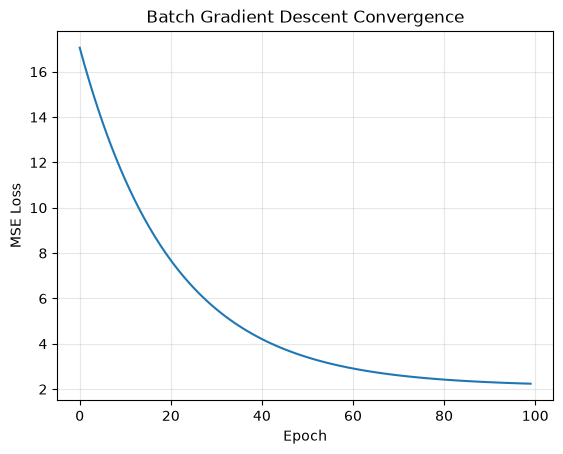

In [ ]:
# GRADIENT DESCENT FAMILY

# Batch Gradient Descent on Linear Regression
# Generate synthetic data: y = 3x + 2 + noise

np.random.seed(123)
n_samples = 100
X = np.random.randn(n_samples, 1)
true_w = np.array([[3.0]])
true_b = np.array([2.0])
y = X @ true_w + true_b + np.random.randn(n_samples, 1) * 1.5

# Initialize parameters
W = np.random.randn(1, 1) * 0.1
b = np.zeros(1)
lr = 0.01
n_epochs = 100
losses = []

for epoch in range(n_epochs):
    # Forward: y_pred = X @ W + b
    y_pred = X @ W + b
    
    # MSE loss
    loss = np.mean((y_pred - y)**2)
    losses.append(loss)
    
    # Gradients (derived analytically)
    # dL/dW = (2/n) * X^T @ (y_pred - y)
    dW = (2 / n_samples) * X.T @ (y_pred - y)
    db = (2 / n_samples) * np.sum(y_pred - y)
    
    # Update
    W -= lr * dW
    b -= lr * db

print(f"True W: {true_w.flatten()}, Learned W: {W.flatten()}")
print(f"True b: {true_b}, Learned b: {b}")
print(f"Final loss: {loss:.6f}")

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Batch Gradient Descent Convergence')
plt.grid(True, alpha=0.3)
plt.show()

# MSE = Mean Squared Error.
# For each sample, take prediction minus true value, square it, then average:
# In code:
# loss = np.mean((y_pred - y)**2)
# Squaring makes all errors positive and penalizes big mistakes more
# Mean averages over all samples

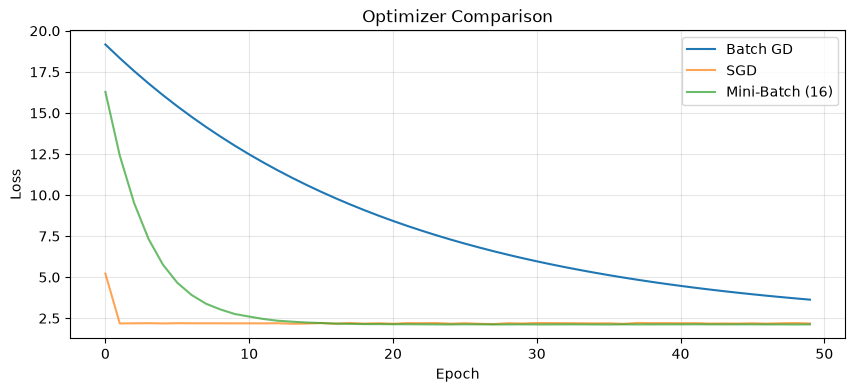

In [ ]:
# Compare GD, SGD, Mini-Batch GD

def train_with_optimizer(X, y, optimizer='batch', lr=0.01, batch_size=16, n_epochs=50):
    n_samples = X.shape[0]
    W = np.random.randn(1, 1) * 0.1
    b = np.zeros(1)
    losses = []

    for epoch in range(n_epochs):
        if optimizer == 'batch':
            # Full batch
            y_pred = X @ W + b
            loss = np.mean((y_pred - y)**2)
            dW = (2 / n_samples) * X.T @ (y_pred - y)
            db = (2 / n_samples) * np.sum(y_pred - y)
            W -= lr * dW
            b -= lr * db
            losses.append(loss)

        elif optimizer == 'sgd':
            # Stochastic: one random sample per step
            epoch_loss = 0
            for i in np.random.permutation(n_samples):
                xi = X[i:i+1]
                yi = y[i:i+1]
                y_pred = xi @ W + b
                loss_i = np.mean((y_pred - yi)**2)
                dW = 2 * xi.T @ (y_pred - yi)
                db = 2 * np.sum(y_pred - yi)
                W -= lr * dW
                b -= lr * db
                epoch_loss += loss_i
            losses.append(epoch_loss / n_samples)
        
        elif optimizer == 'mini-batch':
            # Mini-batch
            indices = np.random.permutation(n_samples)
            epoch_loss = 0
            for start in range(0, n_samples, batch_size):
                batch_idx = indices[start:start+batch_size]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                y_pred = X_batch @ W + b
                loss_batch = np.mean((y_pred - y_batch)**2)
                dW = (2 / len(batch_idx)) * X_batch.T @ (y_pred - y_batch)
                db = (2 / len(batch_idx)) * np.sum(y_pred - y_batch)
                W -= lr * dW
                b -= lr * db
                epoch_loss += loss_batch * len(batch_idx)
            losses.append(epoch_loss / n_samples)
    
    return losses

losses_batch = train_with_optimizer(X, y, 'batch', lr=0.01)
losses_sgd = train_with_optimizer(X, y, 'sgd', lr=0.01)
losses_minibatch = train_with_optimizer(X, y, 'mini-batch', lr=0.01, batch_size=16)

plt.figure(figsize=(10, 4))
plt.plot(losses_batch, label='Batch GD')
plt.plot(losses_sgd, label='SGD', alpha=0.7)
plt.plot(losses_minibatch, label='Mini-Batch (16)', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Optimizer Comparison')
plt.grid(True, alpha=0.3)
plt.show()

# Observations: SGD is noisy but can escape local minima. Mini-batch gives a good balance of speed and stability. 
# This trade-off is why Adam is so popular.

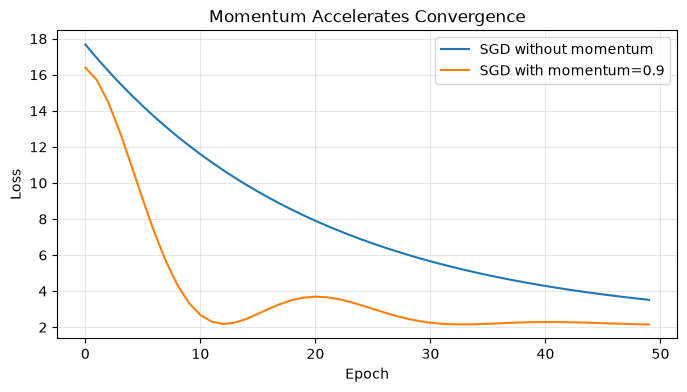

In [ ]:
# Momentum - Faster Convergence

def train_momentum(X, y, lr=0.01, momentum=0.9, n_epochs=50):
    n_samples = X.shape[0]
    W = np.random.randn(1, 1) * 0.1
    b = np.zeros(1)
    v_W = np.zeros_like(W)
    v_b = np.zeros_like(b)
    losses = []

    for epoch in range(n_epochs):
        y_pred = X @ W + b
        loss = np.mean((y_pred - y)**2)
        losses.append(loss)
        
        dW = (2 / n_samples) * X.T @ (y_pred - y)
        db = (2 / n_samples) * np.sum(y_pred - y)
        
        # Velocity update
        v_W = momentum * v_W - lr * dW
        v_b = momentum * v_b - lr * db
        
        W += v_W
        b += v_b
    
    return losses, W, b

losses_mom, W_mom, b_mom = train_momentum(X, y, lr=0.01, momentum=0.9)
losses_plain, W_plain, b_plain = train_momentum(X, y, lr=0.01, momentum=0.0)  # no momentum

plt.figure(figsize=(8, 4))
plt.plot(losses_plain, label='SGD without momentum')
plt.plot(losses_mom, label='SGD with momentum=0.9')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Momentum Accelerates Convergence')
plt.show()

# Epoch — one full pass through the training data.
# Loss — a number measuring how wrong the predictions are.
# Momentum helps by averaging out the noise in the gradient.
# Insight: Momentum accumulates a velocity vector, smoothing oscillations and accelerating down ravines. 
# Almost all modern optimizers use some form of momentum.

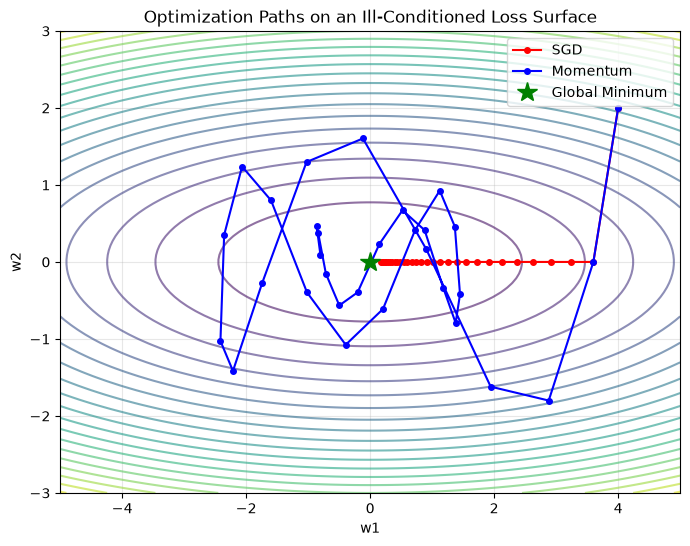

In [48]:
# Visualize the Loss Landscape and Optimizer Paths

# Create a simple 2D loss function: L(w1, w2) = w1^2 + 10*w2^2 (elliptical bowl)
def loss_2d(W):
    return W[0]**2 + 10 * W[1]**2

def grad_2d(W):
    return np.array([2*W[0], 20*W[1]])

# Optimize from same starting point with different methods
start = np.array([4.0, 2.0])

def optimize_2d(start, method='sgd', lr=0.05, n_steps=30):
    W = start.copy()
    path = [W.copy()]
    v = np.zeros(2) if method == 'momentum' else None
    for _ in range(n_steps):
        g = grad_2d(W)
        if method == 'momentum':
            v = 0.9 * v - lr * g
            W += v
        else:
            W -= lr * g
        path.append(W.copy())
    return np.array(path)

path_sgd = optimize_2d(start, 'sgd', lr=0.05)
path_mom = optimize_2d(start, 'momentum', lr=0.05)

# Plot contours and paths
w1 = np.linspace(-5, 5, 100)
w2 = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1, w2)
Z = W1**2 + 10*W2**2

plt.figure(figsize=(8, 6))
plt.contour(W1, W2, Z, levels=20, cmap='viridis', alpha=0.6)
plt.plot(path_sgd[:, 0], path_sgd[:, 1], 'r-o', markersize=4, label='SGD')
plt.plot(path_mom[:, 0], path_mom[:, 1], 'b-o', markersize=4, label='Momentum')
plt.plot(0, 0, 'g*', markersize=15, label='Global Minimum')
plt.xlabel('w1'); plt.ylabel('w2')
plt.legend()
plt.title('Optimization Paths on an Ill-Conditioned Loss Surface')
plt.grid(True, alpha=0.3)
plt.show()

# Key lesson: SGD zig-zags in narrow valleys. Momentum smooths the path. 
# the graph is a visual demo that momentum helps on ill-conditioned (ravine-like) loss landscapes.

Principal components (columns):
[[ 0.70039896  0.71375157]
 [ 0.71375157 -0.70039896]]
Explained variance: [5.04600292 0.46513918]
Proportion: [0.91560022 0.08439978]


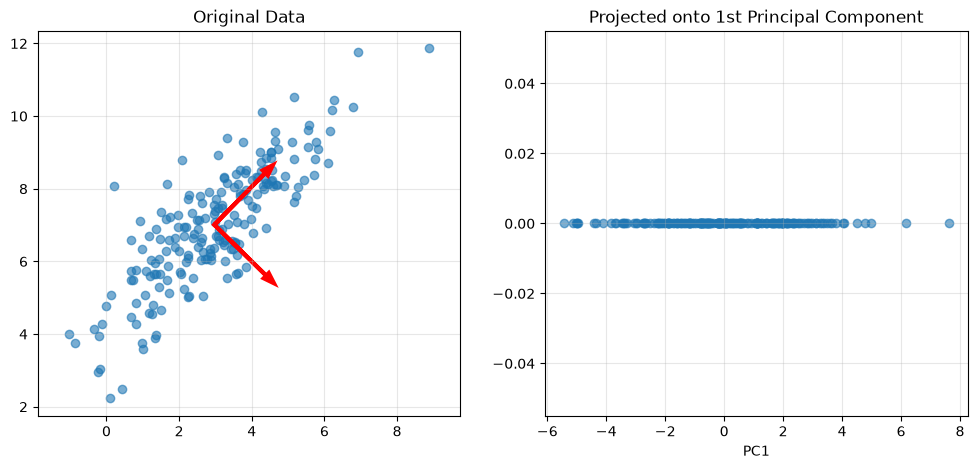

In [55]:
# DIMENSIONALITY REDUCTION

# PCA from Scratch Using SVD

# Generate correlated 2D data
np.random.seed(42)
mean = [3, 7]
cov = [[3, 2.5], [2.5, 3]]  # correlated
X = np.random.multivariate_normal(mean, cov, 200)

# Step 1: Center the data
X_centered = X - X.mean(axis=0)

# Step 2: Singular Value Decomposition of centered data
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Principal components are rows of Vt (or columns of V)
principal_components = Vt.T  # each column is a PC
explained_variance = (S**2) / (X_centered.shape[0] - 1)

print(f"Principal components (columns):\n{principal_components}")
print(f"Explained variance: {explained_variance}")
print(f"Proportion: {explained_variance / explained_variance.sum()}")

# Project data onto first PC
X_pca_1d = X_centered @ principal_components[:, 0]

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], alpha=0.6)
axes[0].set_title('Original Data')
mean_vec = X.mean(axis=0)

for i, pc in enumerate(principal_components.T):
    axes[0].arrow(mean_vec[0], mean_vec[1], pc[0]*2, pc[1]*2, 
                  head_width=0.2, head_length=0.3, fc='red', ec='red', linewidth=3)
axes[0].axis('equal')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_pca_1d, np.zeros_like(X_pca_1d), alpha=0.6)
axes[1].set_title('Projected onto 1st Principal Component')
axes[1].set_xlabel('PC1')
axes[1].grid(True, alpha=0.3)
plt.show()

# Takeaway: PCA finds the best axes for the data’s variance; 
# projecting onto PC1 is a simple dimensionality reduction from 2D → 1D.
# PCA finds the directions (principal components) of maximum variance. The first PC captures the most information. 
# In machine learning, this is used for feature reduction and noise filtering.

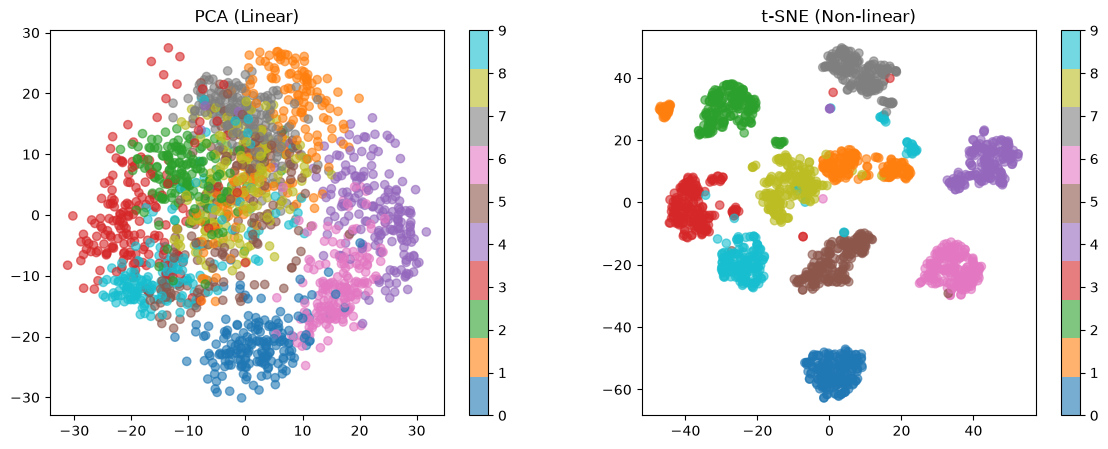

PCA preserves global structure, t-SNE reveals local clusters.
t-SNE is great for visualization but doesn't give a transform for new data.


In [ ]:
# Compare PCA with sklearn and t-SNE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Use digits dataset for a realistic example
from sklearn.datasets import load_digits
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# PCA with sklearn (should match our SVD approach)
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_digits)

# t-SNE (good for visualization, not for reconstruction)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_2d = tsne.fit_transform(X_digits)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_digits, cmap='tab10', alpha=0.6)
axes[0].set_title('PCA (Linear)')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=y_digits, cmap='tab10', alpha=0.6)
axes[1].set_title('t-SNE (Non-linear)')
plt.colorbar(sc2, ax=axes[1])
plt.show()

print("PCA preserves global structure, t-SNE reveals local clusters.")
print("t-SNE is great for visualization but doesn't give a transform for new data.")

# Why this matters later: When you build RAG (retrieval-augmented generation), you'll use embeddings to represent text. 
# PCA/t-SNE help you visualize if your embeddings are well-separated.

# PCA is a simple linear “best axes” view; t-SNE often shows nicer class clusters for eyeballing, 
# but PCA is more stable and useful as an actual feature transform.

In [6]:
# NUMERICAL STABILITY

# The Softmax Stability Trick

def softmax_unstable(logits):
    """Naive softmax — can overflow for large logits"""
    exp_vals = np.exp(logits)
    return exp_vals / np.sum(exp_vals)

def softmax_stable(logits):
    """Subtract max for numerical stability"""
    logits_shifted = logits - np.max(logits)
    exp_vals = np.exp(logits_shifted)
    return exp_vals / np.sum(exp_vals)

# Test with moderate values
logits_moderate = np.array([2.0, 1.0, 0.1])
print("Moderate logits:")
print("Unstable:", softmax_unstable(logits_moderate))
print("Stable:  ", softmax_stable(logits_moderate))

# Test with extreme values (unstable version may overflow)
logits_extreme = np.array([1000.0, 1000.0, 1000.0])
print("\nExtreme logits (1000s):")
# Unstable will overflow to inf -> nan
# Uncomment carefully:
# print("Unstable:", softmax_unstable(logits_extreme))  # likely [nan, nan, nan]
print("Stable:  ", softmax_stable(logits_extreme))  # correct [0.333, 0.333, 0.333]

# Takeaway: always use the stable form (libraries like PyTorch do this internally) so 
# large logits don’t blow up training. Always use the log-sum-exp trick when implementing softmax or cross-entropy. 
# It's the difference between a model that trains and one that explodes into NaNs.


Moderate logits:
Unstable: [0.65900114 0.24243297 0.09856589]
Stable:   [0.65900114 0.24243297 0.09856589]

Extreme logits (1000s):
Stable:   [0.33333333 0.33333333 0.33333333]


In [9]:
# Log-Sum-Exp for Stable Cross-Entropy

def cross_entropy_stable(logits, target_class):
    """Compute cross-entropy loss without ever computing full softmax."""
    # logits: raw scores (before softmax)
    # target_class: integer index of true class
    logits_stable = logits - np.max(logits)  # shift
    # log(softmax)_i = logits_stable[i] - log(sum(exp(logits_stable)))
    log_sum_exp = np.log(np.sum(np.exp(logits_stable)))
    log_prob_true = logits_stable[target_class] - log_sum_exp
    return -log_prob_true

# Example
logits = np.array([2.0, 1.0, 0.1])
loss = cross_entropy_stable(logits, target_class=0)
print(f"Cross-entropy loss (stable): {loss:.4f}")

# Compare with PyTorch-style (using softmax then log)
probs = softmax_stable(logits)
loss_naive = -np.log(probs[0])
print(f"Cross-entropy via softmax: {loss_naive:.4f}")

# Takeaway: Log-sum-exp trick is stable and efficient. It's the difference between a model that trains and one that explodes.
# It's used in many places, including softmax and cross-entropy.

# This is how PyTorch's nn.CrossEntropyLoss works internally. 
# It combines softmax and NLLLoss in a numerically stable way.

Cross-entropy loss (stable): 0.4170
Cross-entropy via softmax: 0.4170


In [11]:
summary_day2 = """
DAY 2 KEY INSIGHTS:

1. DERIVATIVES & GRADIENTS:
   - Derivative = slope. Gradient = vector of partial derivatives.
   - Gradient points to steepest ascent. Move opposite to minimize.
   - Chain rule: d f(g(x)) / dx = f'(g(x)) * g'(x) — multiply local gradients.

2. BACKPROPAGATION:
   - Forward pass: compute & store all intermediate values.
   - Backward pass: start from loss, multiply gradients backward via chain rule.
   - Gradient checking is the ultimate debugger.

3. OPTIMIZATION:
   - Batch GD: stable but slow on big data.
   - SGD: fast, noisy, can escape local minima.
   - Mini-batch: best of both worlds.
   - Momentum: accelerates by accumulating velocity.
   - Adam (preview): adaptive learning rates per parameter.

4. PCA & SVD:
   - PCA finds directions of maximum variance.
   - SVD gives eigenvectors of covariance directly.
   - t-SNE visualizes high-dimensional clusters.

5. NUMERICAL STABILITY:
   - Softmax: subtract max(logits) before exp.
   - Cross-entropy: use log-sum-exp, not log(softmax).
   - These tricks prevent NaN and make training stable.
"""
print(summary_day2)


DAY 2 KEY INSIGHTS:

1. DERIVATIVES & GRADIENTS:
   - Derivative = slope. Gradient = vector of partial derivatives.
   - Gradient points to steepest ascent. Move opposite to minimize.
   - Chain rule: d f(g(x)) / dx = f'(g(x)) * g'(x) — multiply local gradients.

2. BACKPROPAGATION:
   - Forward pass: compute & store all intermediate values.
   - Backward pass: start from loss, multiply gradients backward via chain rule.
   - Gradient checking is the ultimate debugger.

3. OPTIMIZATION:
   - Batch GD: stable but slow on big data.
   - SGD: fast, noisy, can escape local minima.
   - Mini-batch: best of both worlds.
   - Momentum: accelerates by accumulating velocity.
   - Adam (preview): adaptive learning rates per parameter.

4. PCA & SVD:
   - PCA finds directions of maximum variance.
   - SVD gives eigenvectors of covariance directly.
   - t-SNE visualizes high-dimensional clusters.

5. NUMERICAL STABILITY:
   - Softmax: subtract max(logits) before exp.
   - Cross-entropy: use log-s

iter   0  loss=4.725974
  grad check W1: relative error = 1.10e-09
  grad check b1: relative error = 1.05e-09
  grad check W2: relative error = 2.24e-10
  grad check b2: relative error = 1.45e-10
iter  10  loss=2.732326
iter  20  loss=2.509497
iter  30  loss=2.455395
iter  40  loss=2.436706
iter  50  loss=2.428763
  grad check W1: relative error = 2.42e-09
  grad check b1: relative error = 1.83e-09
  grad check W2: relative error = 1.48e-09
  grad check b2: relative error = 3.65e-09
iter  60  loss=2.424549
iter  70  loss=2.422517
iter  80  loss=2.418660
iter  90  loss=2.411400
iter 100  loss=2.395224
  grad check W1: relative error = 1.87e-09
  grad check b1: relative error = 3.40e-10
  grad check W2: relative error = 1.19e-09
  grad check b2: relative error = 7.09e-11
iter 110  loss=2.362689
iter 120  loss=2.307525
iter 130  loss=2.222598
iter 140  loss=2.121360
iter 150  loss=2.007411
  grad check W1: relative error = 1.50e-09
  grad check b1: relative error = 7.13e-10
  grad check W

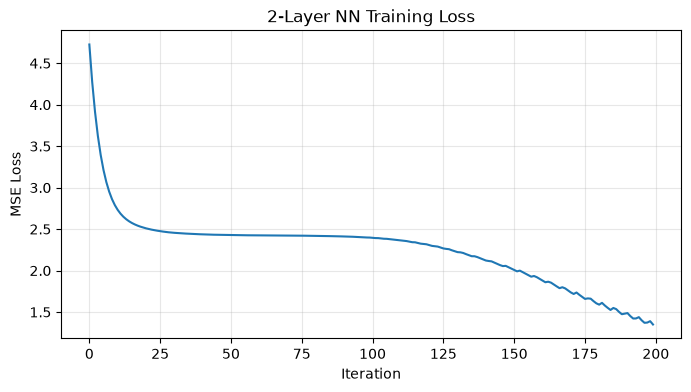

In [14]:
# CHALLENGE: Implement a simple 2-layer neural network (as in Cell 4) but
# train it on a tiny regression dataset using gradient descent.
# Use the gradient checking to verify your backward pass.
# Plot the loss curve.

# Steps:
# 1. Create synthetic data: X (10 samples, 2 features), y = some nonlinear function
# 2. Initialize weights randomly
# 3. Loop: forward, compute loss (MSE), backward (compute all gradients manually), update
# 4. Every 10 iterations, print loss and check gradients occasionally
# 5. Plot loss vs iteration


# code
# CHALLENGE: 2-layer NN + GD + gradient check + loss plot

np.random.seed(0)

# 1) Synthetic data: y = nonlinear function of 2 features
n_samples = 10
X = np.random.randn(n_samples, 2)
y = np.sin(X[:, 0:1]) + X[:, 1:2]**2   # both (10, 1)

# 2) Init weights (same shapes as Cell 3: 2 → 3 hidden → 1)
W1 = np.random.randn(3, 2) * 0.1
b1 = np.zeros(3)
W2 = np.random.randn(1, 3) * 0.1
b2 = np.zeros(1)

lr = 0.05
n_iters = 200
losses = []

def forward(X_batch):
    """Returns y_pred and cache for backward."""
    z1 = X_batch @ W1.T + b1          # (n, 3)
    h = np.maximum(0, z1)             # ReLU
    y_pred = h @ W2.T + b2            # (n, 1)
    return y_pred, z1, h

def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def backward(X_batch, y_true, y_pred, z1, h):
    n = X_batch.shape[0]
    # dL/dy_pred
    dL_dy = (2.0 / n) * (y_pred - y_true)   # (n, 1)

    dW2 = dL_dy.T @ h                       # (1, 3)
    db2 = np.sum(dL_dy, axis=0)             # (1,)

    dL_dh = dL_dy @ W2                      # (n, 3)
    dL_dz1 = dL_dh * (z1 > 0)               # ReLU mask

    dW1 = dL_dz1.T @ X_batch                # (3, 2)
    db1 = np.sum(dL_dz1, axis=0)            # (3,)
    return dW1, db1, dW2, db2

def gradient_check(param_name, param, analytical, h=1e-6):
    numerical = np.zeros_like(param)
    it = np.nditer(param, flags=["multi_index"])
    while not it.finished:
        idx = it.multi_index
        old = param[idx]
        param[idx] = old + h
        yp, _, _ = forward(X)
        loss_plus = mse_loss(yp, y)
        param[idx] = old - h
        yp, _, _ = forward(X)
        loss_minus = mse_loss(yp, y)
        param[idx] = old
        numerical[idx] = (loss_plus - loss_minus) / (2 * h)
        it.iternext()
    rel = np.linalg.norm(analytical - numerical) / (
        np.linalg.norm(analytical) + np.linalg.norm(numerical) + 1e-8
    )
    print(f"  grad check {param_name}: relative error = {rel:.2e}")

# 3–4) Train
for t in range(n_iters):
    y_pred, z1, h = forward(X)
    loss = mse_loss(y_pred, y)
    losses.append(loss)

    dW1, db1, dW2, db2 = backward(X, y, y_pred, z1, h)

    if t % 10 == 0:
        print(f"iter {t:3d}  loss={loss:.6f}")
        if t % 50 == 0:  # occasional full check
            gradient_check("W1", W1, dW1)
            gradient_check("b1", b1, db1)
            gradient_check("W2", W2, dW2)
            gradient_check("b2", b2, db2)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# 5) Plot
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("2-Layer NN Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
### What the challenge asks
# Build the same tiny 2-layer net from earlier cells, but train it end-to-end:
# 1. Make fake regression data  
# 2. Init weights  
# 3. Repeat: forward → MSE → manual backward → update  
# 4. Print loss / gradient-check sometimes  
# 5. Plot loss vs iteration  

# Goal: prove you can wire forward + backward + GD yourself, and verify grads with finite differences.

# ---

# ### Architecture
# ```
# X (10×2) → Linear(W1,b1) → ReLU → Linear(W2,b2) → y_pred (10×1)
# ```
# - Hidden size 3  
# - Nonlinear target: \(y = \sin(x_1) + x_2^2\) so a linear model alone isn’t enough

# ---

# ### Implementation pieces

# 1. Data  
# 10 random 2D points; labels from that nonlinear formula. Shapes stay `(10, 1)` via `X[:, 0:1]` and `X[:, 1:2]`.

# 2. Weights  
# - `W1` `(3,2)`, `b1` `(3,)` — input → hidden  
# - `W2` `(1,3)`, `b2` `(1,)` — hidden → output  

# 3. `forward`  
# ```
# z1 = X @ W1.T + b1
# h  = ReLU(z1) = max(0, z1)
# y_pred = h @ W2.T + b2
# ```
# Returns `z1` and `h` so backward can reuse them.

# 4. `mse_loss`  
# Average squared error: how far predictions are from `y`.

# 5. `backward` (chain rule)  
# - Start from \(\partial L/\partial\hat{y}\)  
# - Grads for `W2`, `b2`  
# - Propagate to hidden, apply ReLU mask `(z1 > 0)`  
# - Grads for `W1`, `b1`  

# Same idea as Cell 3, but for a batch of 10 (hence the `2/n` factor).

# 6. `gradient_check`  
# For each weight entry: nudge ±ε, measure loss change numerically, compare to your analytical grad. Relative error ≪ `1e-5` ⇒ backward is correct.

# 7. Training loop  
# Each iteration: forward → loss → backward → `param -= lr * grad`. Every 10 steps print loss; every 50 run gradient checks.

# 8. Plot  
# Loss vs iteration should trend down if learning works.

# ---

# ### Mental model of one step
# ```
# predict → measure error → ask “which way to nudge each weight?” → nudge → repeat
# ```
# Gradient check is the debugger: if training looks weird, check whether those “which way” answers match the numerical slope.